# Imports

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

import sklearn.svm as svm
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import classification_report, accuracy_score

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay



---


# Loading Dataset

In [2]:
df = pd.read_csv('/content/Iris.csv', index_col=0)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa




---

# Data Preprocessing

## Cleaning

In [3]:
print(f"Number of nulls: {df.isna().sum().sum()}")
print(f"Number of duplicates: {df.duplicated().sum()}")

Number of nulls: 0
Number of duplicates: 3


In [4]:
df.drop_duplicates(inplace=True)

In [5]:
X = df.drop('Species', axis=1)
y = df['Species']

## One Hot Encoding

In [6]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_encoded

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

## Splitting

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

## Normalization

In [8]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Exploratory Data Analysis

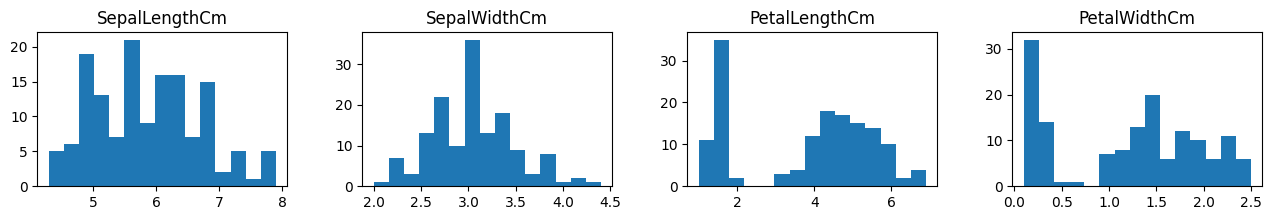

In [9]:
df.hist(figsize=(20, 2), grid=False, bins=15, layout=(1,5))
plt.show()

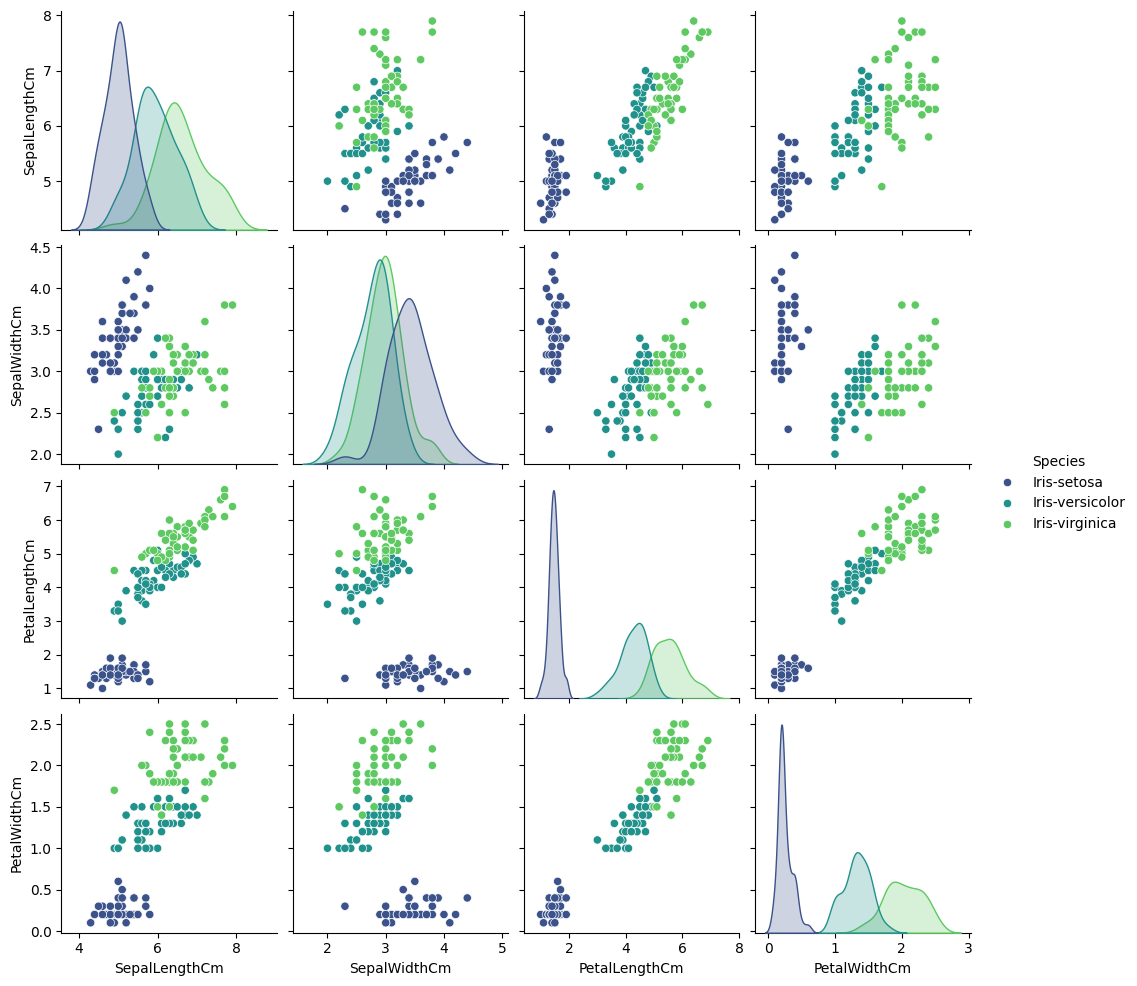

In [10]:
sns.pairplot(df, hue='Species', palette='viridis')
plt.show()



---


# Support Vector Machine

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      0.92      0.96        12
           2       0.94      1.00      0.97        16

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.98        45
weighted avg       0.98      0.98      0.98        45



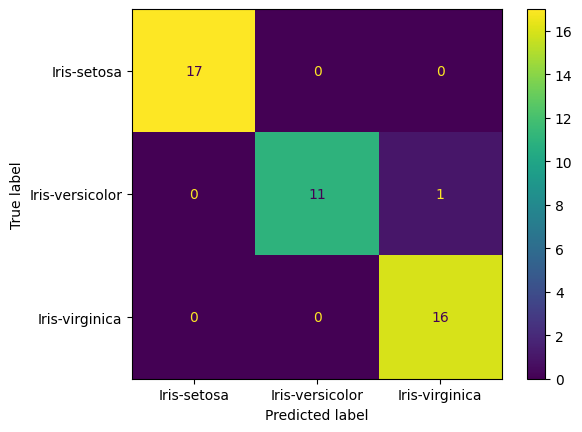

In [11]:
model_svm = svm.SVC(kernel='linear')
model_svm.fit(X_train, y_train)
y_pred = model_svm.predict(X_test)

print(classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(conf_matrix, display_labels=y.unique()).plot()
plt.show()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      0.92      0.96        12
           2       0.94      1.00      0.97        16

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.98        45
weighted avg       0.98      0.98      0.98        45



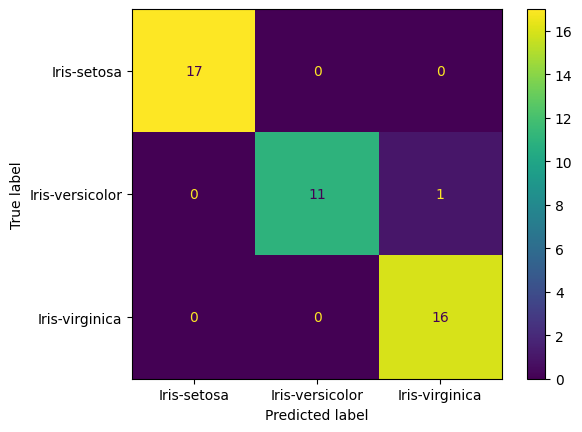

In [12]:
model_svm = svm.SVC(kernel='poly')
model_svm.fit(X_train, y_train)
y_pred = model_svm.predict(X_test)

print(classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(conf_matrix, display_labels=y.unique()).plot()
plt.show()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       0.92      0.92      0.92        12
           2       0.94      0.94      0.94        16

    accuracy                           0.96        45
   macro avg       0.95      0.95      0.95        45
weighted avg       0.96      0.96      0.96        45



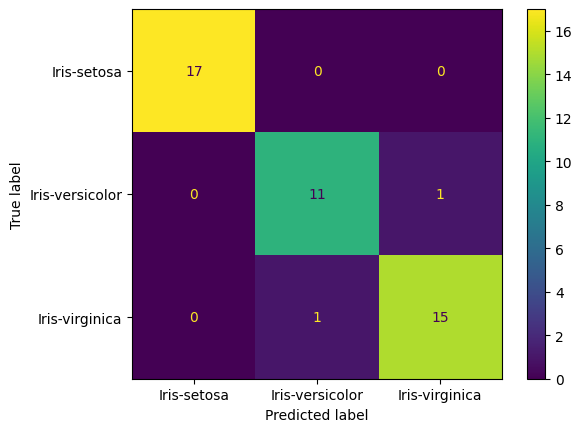

In [13]:
model_svm = svm.SVC(kernel='rbf')
model_svm.fit(X_train, y_train)
y_pred = model_svm.predict(X_test)

print(classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(conf_matrix, display_labels=y.unique()).plot()
plt.show()



---

# Neural Network

In [14]:
y_encoded_onehot_train = to_categorical(y_train)
y_encoded_onehot_train[:5]

array([[0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [15]:
callback = EarlyStopping(monitor='loss', patience=3)

## Activation ReLU + Softmax

In [16]:
model_nn = Sequential()
model_nn.add( Input(shape=(4,)) ) # Input Layer
model_nn.add( Dense(units=10, activation='relu') ) # Hidden Layer
model_nn.add( Dense(units=8, activation='relu') ) # Hidden Layer
model_nn.add( Dense(units=3, activation='softmax') ) # Output Lyaer

In [17]:
model_nn.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
y_pred = model_nn.fit(X_train, y_train, epochs=100, callbacks=[callback])

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3855 - loss: 2.7425
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3678 - loss: 2.7319 
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3719 - loss: 2.4075
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3876 - loss: 2.1030
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3615 - loss: 2.0932
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3459 - loss: 1.9292
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4115 - loss: 1.6805
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3709 - loss: 1.6492
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3709 - loss: 1.4999 
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4042 - loss: 1.3832
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3896 - loss: 1.3433
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3553 - 

In [18]:
model_nn.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


array([[0.09619619, 0.39366516, 0.51013863],
       [0.19577955, 0.41037217, 0.39384824],
       [0.04504507, 0.33166763, 0.6232873 ],
       [0.6701409 , 0.27000082, 0.05985834],
       [0.09362455, 0.37496445, 0.53141093],
       [0.70514333, 0.23873094, 0.05612566],
       [0.15160328, 0.4215548 , 0.4268419 ],
       [0.68247664, 0.25836477, 0.0591586 ],
       [0.09845956, 0.38493901, 0.51660144],
       [0.70004493, 0.24316859, 0.05678643],
       [0.637029  , 0.28751865, 0.07545242],
       [0.31563672, 0.4105964 , 0.27376682],
       [0.09033757, 0.37264845, 0.53701395],
       [0.24618804, 0.42031848, 0.3334934 ],
       [0.04621068, 0.35045254, 0.6033367 ],
       [0.16569762, 0.4039238 , 0.43037865],
       [0.69421494, 0.25413564, 0.05164932],
       [0.23783594, 0.4319107 , 0.3302533 ],
       [0.10677637, 0.39566723, 0.4975563 ],
       [0.66228336, 0.2678749 , 0.06984161],
       [0.6523879 , 0.27509072, 0.07252127],
       [0.06772957, 0.36611742, 0.566153  ],
       [0.

## Activation Sigmoid + Softmax

In [19]:
model_nn = Sequential()
model_nn.add( Input(shape=(4,)) ) # Input Layer
model_nn.add( Dense(units=10, activation='sigmoid') ) # Hidden Layer
model_nn.add( Dense(units=8, activation='sigmoid') ) # Hidden Layer
model_nn.add( Dense(units=3, activation='softmax') ) # Output Lyaer

In [20]:
model_nn.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
y_pred = model_nn.fit(X_train, y_train, epochs=100, callbacks=[callback])

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4157 - loss: 1.1671
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3678 - loss: 1.1780
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3730 - loss: 1.1844
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3876 - loss: 1.1622
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3386 - loss: 1.1958
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3813 - loss: 1.1714
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3771 - loss: 1.1695 
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3417 - loss: 1.1551 
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3594 - loss: 1.1739
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3959 - loss: 1.1174
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3438 - loss: 1.1417
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3501 - 

## Activation Relu + Sigmoid

In [21]:
model_nn = Sequential()
model_nn.add( Input(shape=(4,)) ) # Input Layer
model_nn.add( Dense(units=10, activation='relu') ) # Hidden Layer
model_nn.add( Dense(units=8, activation='relu') ) # Hidden Layer
model_nn.add( Dense(units=3, activation='sigmoid') ) # Output Lyaer

In [26]:
model_nn.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model_nn.fit(X_train, y_train, epochs=100, callbacks=[callback]) # Assign the output to history

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9755 - loss: 0.3276
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9760 - loss: 0.3137
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9479 - loss: 0.3288
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9755 - loss: 0.3082
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9755 - loss: 0.3141 
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9692 - loss: 0.3048
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9786 - loss: 0.3038
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9846 - loss: 0.3065
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9807 - loss: 0.2973
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9789 - loss: 0.2805
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9841 - loss: 0.2735
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9880 - l

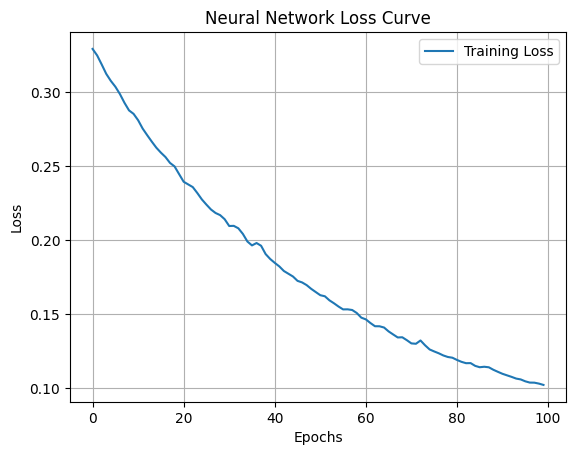

In [30]:
# Plotting the loss curve for the neural network
plt.plot(history.history['loss'], label='Training Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()



 Model Comparison

In [34]:


# Predictions
y_pred_svm = model_svm.predict(X_test)
y_pred_nn = model_nn.predict(X_test) # Changed 'model' to 'model_nn'
y_pred_nn_classes = np.argmax(y_pred_nn, axis=1)

# Classification reports
print("=== SVM Classification Report ===")
print(classification_report(y_test, y_pred_svm, target_names=encoder.classes_))

print("=== Neural Network Classification Report ===")
print(classification_report(y_test, y_pred_nn_classes, target_names=encoder.classes_))

# Accuracy comparison
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_nn = accuracy_score(y_test, y_pred_nn_classes)
print(f"SVM Accuracy: {acc_svm:.4f}")
print(f"Neural Network Accuracy: {acc_nn:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
=== SVM Classification Report ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        17
Iris-versicolor       0.92      0.92      0.92        12
 Iris-virginica       0.94      0.94      0.94        16

       accuracy                           0.96        45
      macro avg       0.95      0.95      0.95        45
   weighted avg       0.96      0.96      0.96        45

=== Neural Network Classification Report ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        17
Iris-versicolor       1.00      0.83      0.91        12
 Iris-virginica       0.89      1.00      0.94        16

       accuracy                           0.96        45
      macro avg       0.96      0.94      0.95        45
   weighted avg       0.96      0.96      0.95        45

SVM Accuracy: 0.9556
Neural Network Accuracy: 0.9556


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


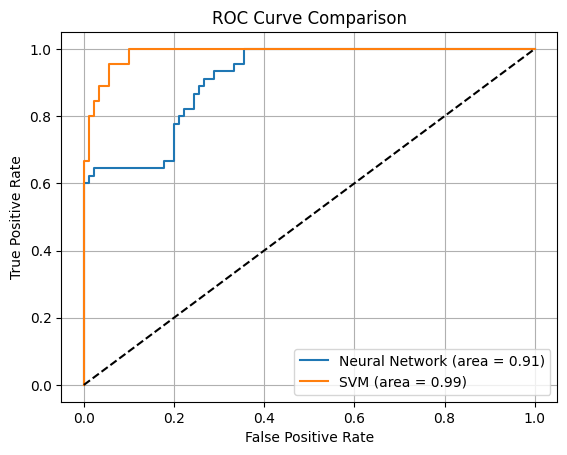

In [33]:

# Binarize the output labels
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Neural network predictions (probabilities)
# Changed 'model' to 'model_nn' to match the variable name used for the neural network
y_score_nn = model_nn.predict(X_test)

# SVM One-vs-Rest for ROC comparison
ovr_svm = OneVsRestClassifier(SVC(kernel="linear", probability=True))
ovr_svm.fit(X_train, label_binarize(y_train, classes=[0, 1, 2]))
y_score_svm = ovr_svm.predict_proba(X_test)

# Plot ROC curves
fpr_nn, tpr_nn, _ = roc_curve(y_test_bin.ravel(), y_score_nn.ravel())
fpr_svm, tpr_svm, _ = roc_curve(y_test_bin.ravel(), y_score_svm.ravel())

roc_auc_nn = auc(fpr_nn, tpr_nn)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure()
plt.plot(fpr_nn, tpr_nn, label='Neural Network (area = {:.2f})'.format(roc_auc_nn))
plt.plot(fpr_svm, tpr_svm, label='SVM (area = {:.2f})'.format(roc_auc_svm))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()